# Параметрический резонанс в уравнении Матье

## Условие задачи

Требуется показать, что при точном параметрическом резонансе амплитуда колебаний растёт со временем экспоненциально.

## Аналитическое решение

Параметрические колебания описываются уравнением Матье
$$ \ddot{x} + \omega_0^2 \left( 1 + h \cos(\gamma t) \right) x = 0, $$
где $h \ll 1$ — глубина модуляции частоты.
Главный параметрический резонанс наступает при частоте модуляции $\gamma = 2\omega_0$, и уравнение принимает вид
$$ \ddot{x} + \omega_0^2 \left( 1 + h \cos(2\omega_0 t) \right) x = 0. $$
Решение ищется методом Ван дер Поля в виде колебаний с медленно меняющимися амплитудами:
$$ x(t) = a(t) \cos(\omega_0 t) + b(t) \sin(\omega_0 t), $$
где $a(t)$ и $b(t)$ — медленные функции времени, для которых $\dot{a} \ll \omega_0 a$, а вторыми производными можно пренебречь.
Производные решения с этой точностью равны
$$ \dot{x} \approx -\omega_0 a \sin(\omega_0 t) + \omega_0 b \cos(\omega_0 t) + \dot{a} \cos(\omega_0 t) + \dot{b} \sin(\omega_0 t), $$
$$ \ddot{x} \approx -\omega_0^2 x + 2\omega_0 \left( \dot{b} \cos(\omega_0 t) - \dot{a} \sin(\omega_0 t) \right). $$
После подстановки в уравнение слагаемые $\mp \omega_0^2 x$ сокращаются:
$$ 2\omega_0 \left( \dot{b} \cos(\omega_0 t) - \dot{a} \sin(\omega_0 t) \right) + \omega_0^2 h \left[ a \cos(2\omega_0 t) \cos(\omega_0 t) + b \cos(2\omega_0 t) \sin(\omega_0 t) \right] = 0. $$
Произведения тригонометрических функций раскладываются по тождествам
$$ \cos(2\omega t) \cos(\omega t) = \frac{1}{2} \left( \cos(3\omega t) + \cos(\omega t) \right), \qquad
\cos(2\omega t) \sin(\omega t) = \frac{1}{2} \left( \sin(3\omega t) - \sin(\omega t) \right). $$
В методе усреднения сохраняются только резонансные слагаемые на частоте $\omega_0$, а быстрые осцилляции на частоте $3\omega_0$ отбрасываются:
$$ 2\omega_0 \dot{b} \cos(\omega_0 t) - 2\omega_0 \dot{a} \sin(\omega_0 t) + \frac{1}{2} \omega_0^2 h a \cos(\omega_0 t) - \frac{1}{2} \omega_0^2 h b \sin(\omega_0 t) = 0. $$
Приравнивание к нулю коэффициентов при $\cos(\omega_0 t)$ и $\sin(\omega_0 t)$ даёт систему линейных уравнений для медленных амплитуд:
$$ \dot{a} = -k b, \qquad \dot{b} = -k a, \qquad k = \frac{\omega_0 h}{4}. $$
Дифференцирование первого уравнения приводит к $\ddot{a} = k^2 a$, откуда
$$ a(t) = C_1 e^{k t} + C_2 e^{-k t}, $$
и аналогично для $b(t)$.
Общее решение содержит растущую экспоненту $e^{k t}$, так что амплитуда колебаний $A(t) = \sqrt{a^2 + b^2}$ растёт экспоненциально с инкрементом
$$ s = \frac{\omega_0 h}{4}. $$
Для начальных условий $x(0) = x_0$, $\dot{x}(0) = 0$ решение усреднённых уравнений имеет вид $a = x_0 \cosh(s t)$, $b = -x_0 \sinh(s t)$, и огибающая колебаний равна
$$ A(t) = x_0 \sqrt{\cosh^2(s t) + \sinh^2(s t)} = x_0 \sqrt{\cosh(2 s t)}, $$
что при $s t \gg 1$ переходит в асимптотику $A(t) \approx \dfrac{x_0}{\sqrt{2}} e^{s t}$.

## Численный расчёт

Уравнение Матье интегрируется численно при $h = 0.1$ и $\gamma = 2\omega_0$.
На первом графике численное решение сравнивается с огибающей $x_0 \sqrt{\cosh(2 s t)}$, на втором в логарифмическом масштабе показаны локальные максимумы координаты вместе с точной огибающей и её асимптотикой.

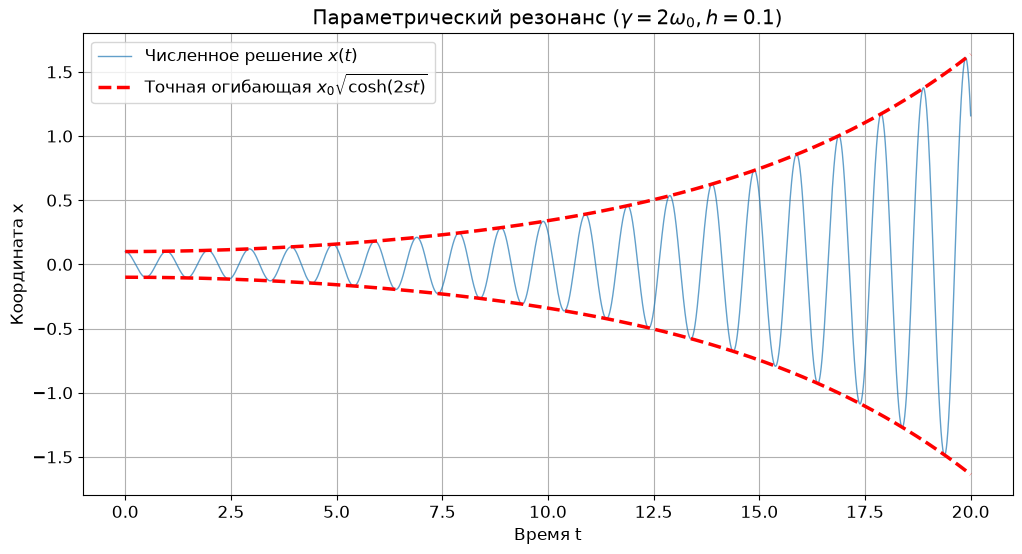

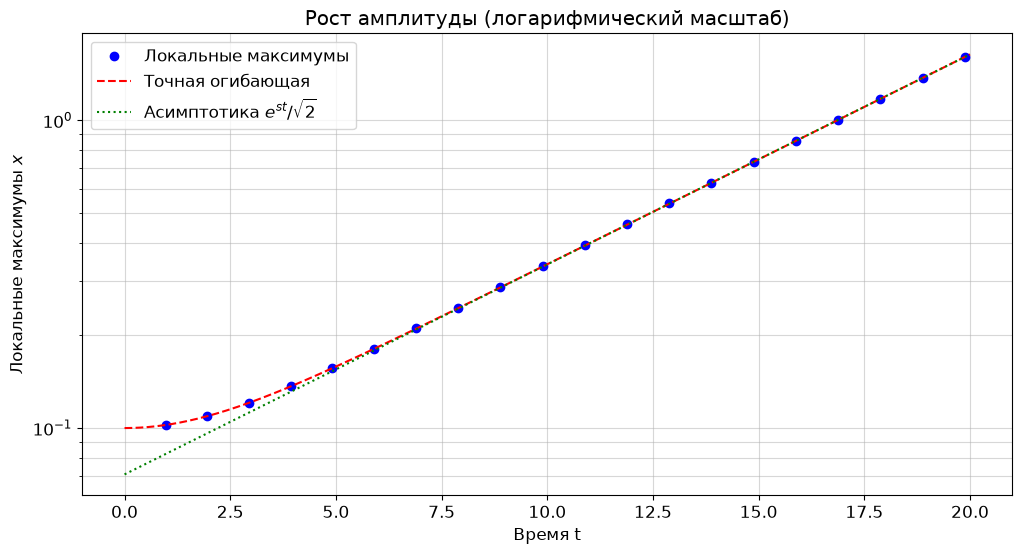

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def mathieu_equation(t, y, omega0, h, gamma):
    """
    Уравнение Матье: x'' + omega0^2 * (1 + h * cos(gamma * t)) * x = 0
    """
    x, v = y
    dxdt = v
    dvdt = -omega0**2 * (1 + h * np.cos(gamma * t)) * x
    return [dxdt, dvdt]

# Параметры
omega0 = 2 * np.pi * 1.0
h = 0.1                  # Глубина модуляции
gamma = 2 * omega0       # Точный резонанс
t_max = 20.0             # Увеличим время
t_eval = np.linspace(0, t_max, 4000)

# Начальные условия
x0 = 0.1
v0 = 0.0
initial_state = [x0, v0]

# Численное решение
sol = solve_ivp(mathieu_equation, [0, t_max], initial_state, t_eval=t_eval, args=(omega0, h, gamma), rtol=1e-9, atol=1e-9)
x = sol.y[0]
t = sol.t

# Теоретическая огибающая
# Инкремент s = omega0 * h / 4
s = omega0 * h / 4

# Точное решение для огибающей при x(0)=x0, v(0)=0:
# A(t) = x0 * sqrt(cosh(2*s*t))
envelope_exact = x0 * np.sqrt(np.cosh(2 * s * t))

# Асимптотика: A(t) ~ (x0 / sqrt(2)) * exp(s*t)
envelope_asymp = (x0 / np.sqrt(2)) * np.exp(s * t)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Численное решение $x(t)$', alpha=0.7, linewidth=1)
plt.plot(t, envelope_exact, 'r--', label=r'Точная огибающая $x_0 \sqrt{\cosh(2st)}$', linewidth=2.5)
plt.plot(t, -envelope_exact, 'r--', linewidth=2.5)

plt.title(rf'Параметрический резонанс ($\gamma = 2\omega_0, h={h}$)')
plt.xlabel('Время t')
plt.ylabel('Координата x')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Проверка экспоненциального роста в логарифмическом масштабе
plt.figure(figsize=(12, 6))
# Берем абсолютные значения пиков
peaks_idx = np.where((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))[0] + 1
# Фильтруем только положительные пики
peaks_idx = peaks_idx[x[peaks_idx] > 0]

plt.semilogy(t[peaks_idx], x[peaks_idx], 'bo', label='Локальные максимумы')
plt.semilogy(t, envelope_exact, 'r--', label='Точная огибающая')
plt.semilogy(t, envelope_asymp, 'g:', label=r'Асимптотика $e^{st}/\sqrt{2}$')

plt.title('Рост амплитуды (логарифмический масштаб)')
plt.xlabel('Время t')
plt.ylabel('Локальные максимумы $x$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

## Итоги

Локальные максимумы численного решения ложатся на огибающую $x_0 \sqrt{\cosh(2 s t)}$, а в логарифмическом масштабе выстраиваются вдоль прямой с наклоном $s = \omega_0 h / 4$.
Это подтверждает, что при точном параметрическом резонансе амплитуда растёт экспоненциально с инкрементом, пропорциональным глубине модуляции.